In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score
from sklearn.ensemble import RandomForestClassifier
sns.set_style("whitegrid")

In [2]:
customer_df = pd.read_csv("cleaned_customer.csv")

print("Dataset Shape:", customer_df.shape)
customer_df.head()

Dataset Shape: (15431, 24)


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,...,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderFrequency,CustomerValue,InactivityScore,ComplaintRate,EngagementScore
0,0,13.0,1,1,26.0,2,1,3.0,3,0,...,20.0,4.0,11.0,1.0,203.22,0.785714,2235.42,0.071429,0.000000,33.0
1,0,5.0,0,3,11.0,4,1,2.0,3,2,...,14.0,2.0,5.0,3.0,165.24,0.833333,826.20,0.500000,0.000000,10.0
2,0,1.0,1,3,15.0,6,0,3.0,4,2,...,23.0,2.0,2.0,5.0,174.07,1.000000,348.14,2.500000,0.333333,6.0
3,0,1.0,1,1,19.0,6,1,4.0,4,4,...,14.0,2.0,2.0,5.0,151.47,1.000000,302.94,2.500000,0.000000,8.0
4,1,9.0,2,3,13.0,4,1,3.0,3,3,...,21.0,1.0,1.0,2.0,122.75,0.285714,122.75,0.470588,0.500000,3.0


In [3]:
print(customer_df["Churn"].value_counts(normalize=True))

Churn
0    0.835655
1    0.164345
Name: proportion, dtype: float64


In [4]:
model_df = customer_df.drop(columns=["FinalCluster"], errors="ignore").copy()

customer_df= customer_df.drop_duplicates()

cat_cols = model_df.select_dtypes(include="object").columns

encoders = {}

for col in model_df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

print("Categorical encoding completed.")

Categorical encoding completed.


In [5]:
X = model_df.drop(["Churn"], axis=1)
y = model_df["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [9]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score: {:.4f}".format(accuracy_score(y_test, y_pred)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[2532   48]
 [  14  493]]

Accuracy Score: 0.9799

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2580
           1       0.91      0.97      0.94       507

    accuracy                           0.98      3087
   macro avg       0.95      0.98      0.96      3087
weighted avg       0.98      0.98      0.98      3087


ROC-AUC Score:
0.997382383071113


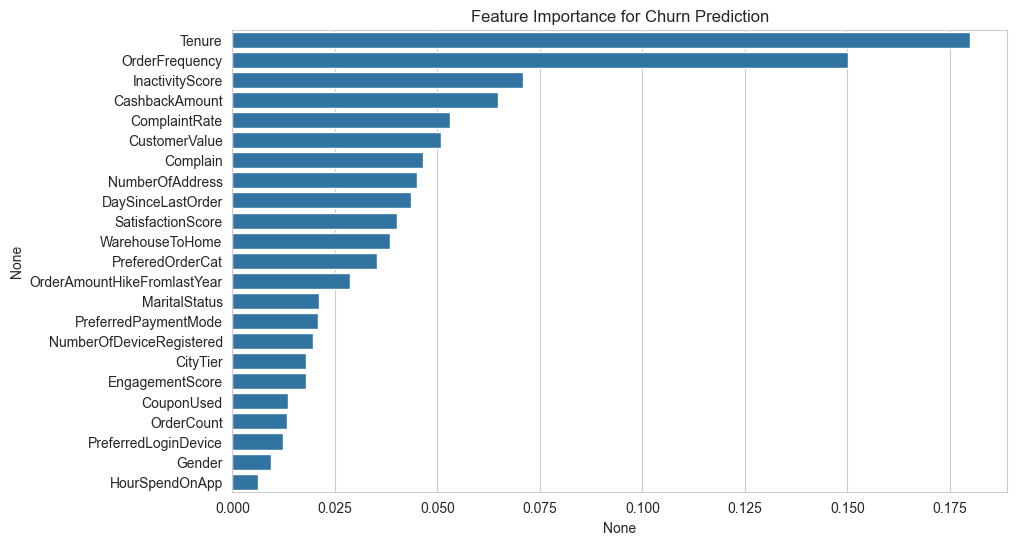

In [10]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance for Churn Prediction")
plt.show()

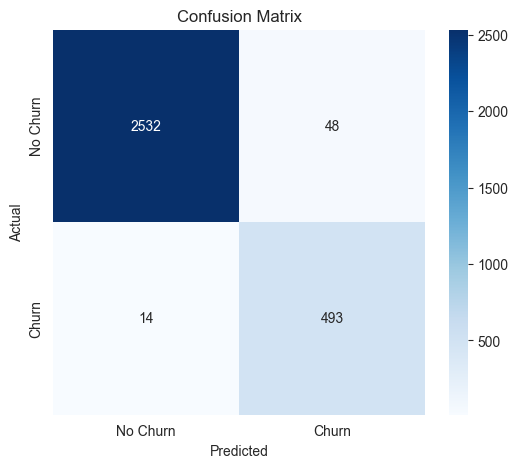

In [11]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
joblib.dump(rf_model,"churn_model.pkl")
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(encoders, "churn_encoders.pkl")
print("Churn prediction model and encoders saved successfully.")

Churn prediction model and encoders saved successfully.
